# Chess Game Outcome Prediction
### Intro to Machine Learning | Final Project

**Dataset:** [Chess Game Dataset (Lichess)](https://www.kaggle.com/datasets/datasnaek/chess)
**Task:** Multiclass Classification — Predict the winner of a chess game (`white`, `black`, or `draw`)
**Dataset size:** ~20,000 games, 16 features

# Setup & Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')


# Load Dataset

In [12]:
DATA_PATH = 'data/games.csv'

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (20058, 16)
Columns: ['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status', 'winner', 'increment_code', 'white_id', 'white_rating', 'black_id', 'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply']


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


# Initial Exploration

In [13]:
print("=== Data Types & Non-Null Counts ===")
df.info()

print("\n=== Summary Statistics (numeric) ===")
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory us

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


In [14]:
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values.")

=== Missing Values ===
No missing values.


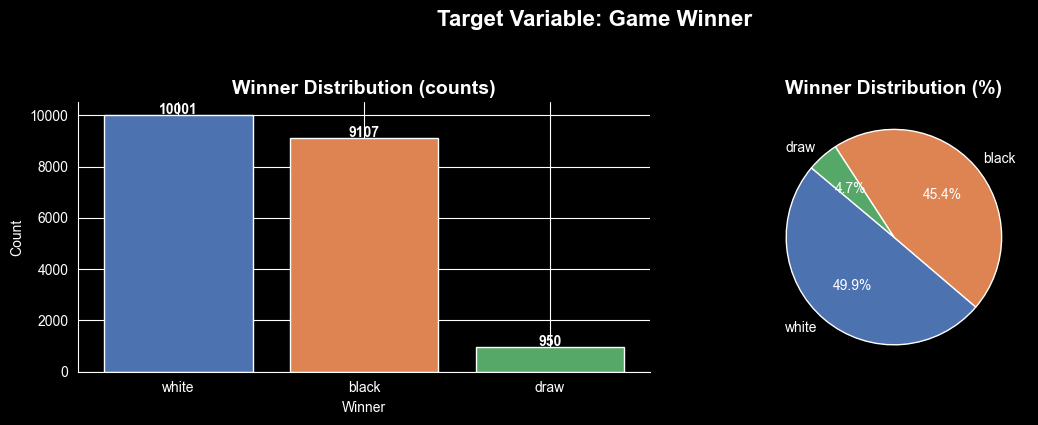

winner
white    10001
black     9107
draw       950
Name: count, dtype: int64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

winner_counts = df['winner'].value_counts()
axes[0].bar(winner_counts.index, winner_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title("Winner Distribution (counts)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Winner")
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(winner_counts.items()):
    axes[0].text(i, val + 50, str(val), ha='center', fontweight='bold')

axes[1].pie(winner_counts.values, labels=winner_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title("Winner Distribution (%)", fontsize=14, fontweight='bold')

plt.suptitle("Target Variable: Game Winner", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figures/fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(winner_counts)

# Feature Engineering & Preprocessing

In [19]:
df_model = df.copy()

# Rating difference (white perspective) ─────────────────────────────────
# Positive indicates white is stronger; negative indicates black is stronger
df_model['rating_diff'] = df_model['white_rating'] - df_model['black_rating']

# Average rating of game ─────────────────────────────────
df_model['avg_rating'] = (df_model['white_rating'] + df_model['black_rating']) / 2

# Encode 'rated' column (binary)  ─────────────────────────────────
df_model['is_rated'] = df_model['rated'].astype(int)

# Parse time control: extract base seconds from increment code  ─────────────────────────────────
def parse_time_control(tc):
    try:
        parts = str(tc).split('+')
        return int(parts[0])
    except:
        return np.nan

df_model['time_base_seconds'] = df_model['increment_code'].apply(parse_time_control)

# Extract time increment  ─────────────────────────────────
def parse_increment(tc):
    try:
        parts = str(tc).split('+')
        return int(parts[1])
    except:
        return 0

df_model['time_increment'] = df_model['increment_code'].apply(parse_increment)

# Label encode game end status (mate, out of time, resign, draw)
le_victory = LabelEncoder()
df_model['victory_status_enc'] = le_victory.fit_transform(df_model['victory_status'].astype(str))
print("Victory status classes:", le_victory.classes_)

print("\nEngineered features preview:")
df_model[['rating_diff', 'avg_rating', 'is_rated', 'time_base_seconds', 'time_increment', 'victory_status_enc']].head()

Victory status classes: ['draw' 'mate' 'outoftime' 'resign']

Engineered features preview:


,rating_diff,avg_rating,is_rated,time_base_seconds,time_increment,victory_status_enc
0,309,1345.5,0,15,2,2
1,61,1291.5,1,5,10,3
2,-4,1498.0,1,5,10,1
3,-15,1446.5,1,20,0,1
4,54,1496.0,1,30,3,1


In [27]:
FEATURES = [
    'rating_diff',
    'avg_rating',
    'is_rated',
    'white_rating',
    'black_rating',
    'turns',
    'opening_ply',
    'time_base_seconds',
    'time_increment',
    'victory_status_enc'
]

TARGET = 'winner'

# Encode target
le_target = LabelEncoder()
df_model['winner_enc'] = le_target.fit_transform(df_model[TARGET])
print("Target classes:", le_target.classes_)
df_model['winner_enc'].head()

X = df_model[FEATURES].copy()
y = df_model['winner_enc'].copy()

# Drop any rows with NaN (from possible time control parsing failures)
nofail = X.notna().all(axis=1)
X, y = X[nofail], y[nofail]

print("\nFinal dataset:", X.shape[0], "samples,", X.shape[1], "features")
print(f"Class distribution:\n{pd.Series(le_target.inverse_transform(y)).value_counts()}")

Target classes: ['black' 'draw' 'white']

Final dataset: 20058 samples, 10 features
Class distribution:
white    10001
black     9107
draw       950
Name: count, dtype: int64
Train: 14040 | Val: 3009 | Test: 3009
Scaling complete


In [28]:
# Train / Val / Test split: 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Scale features  ─────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Train: 14040 | Val: 3009 | Test: 3009
Scaling complete


# Exploratory Data Analysis

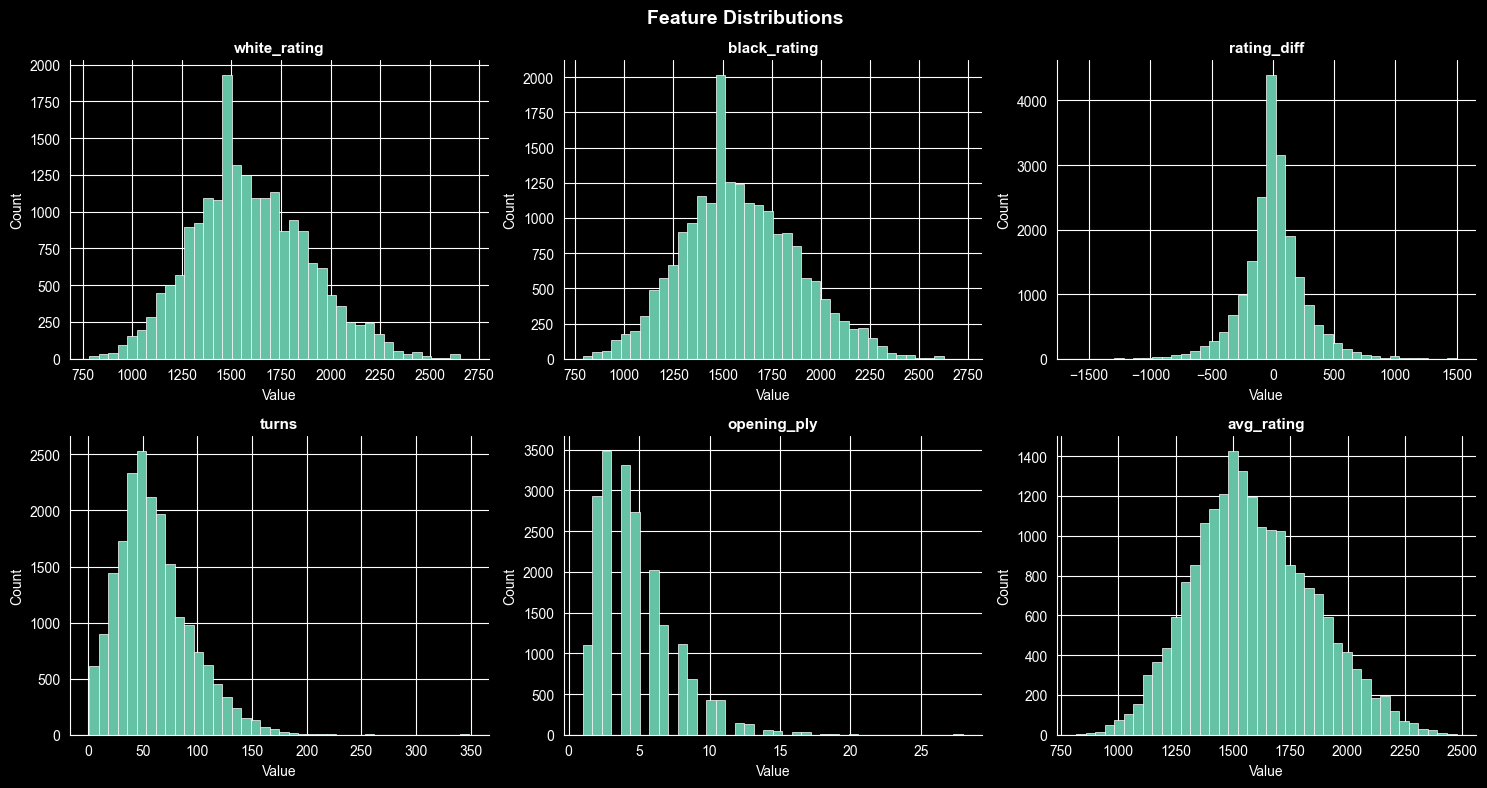

In [30]:
# Numeric feature distributions
numeric_features = ['white_rating', 'black_rating', 'rating_diff', 'turns', 'opening_ply', 'avg_rating']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    axes[i].hist(df_model[feat], bins=40, edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

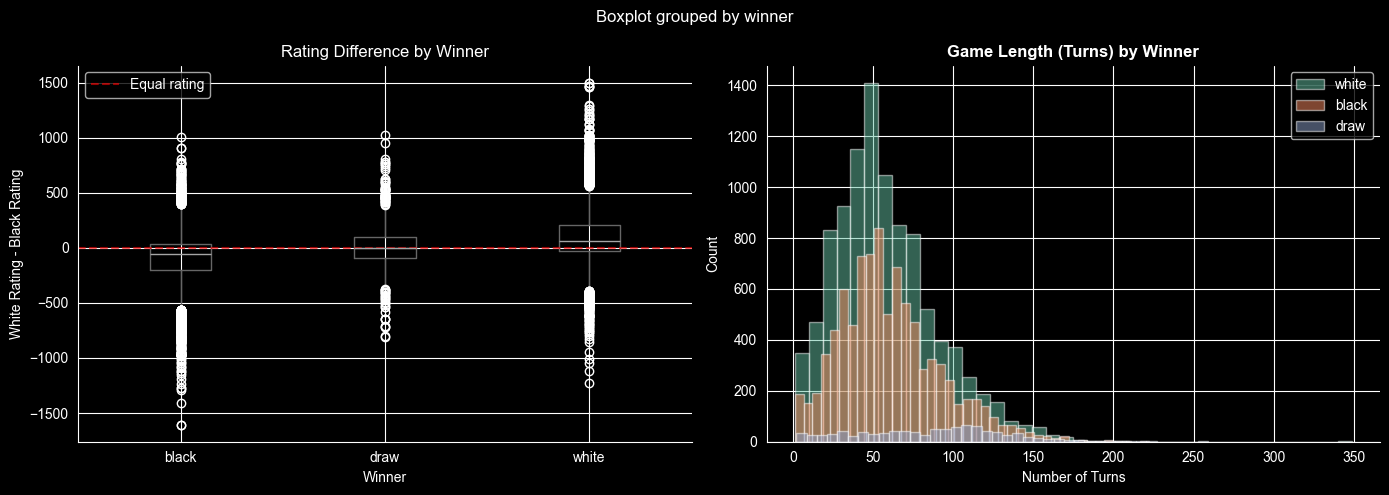

In [31]:
# Rating diff vs. winner
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_model.boxplot(column='rating_diff', by='winner', ax=axes[0])
axes[0].set_title("Rating Difference by Winner", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Winner")
axes[0].set_ylabel("White Rating - Black Rating")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.6, label='Equal rating')
axes[0].legend()
plt.sca(axes[0])
plt.title('Rating Difference by Winner')

for label in df_model['winner'].unique():
    subset = df_model[df_model['winner'] == label]['turns']
    axes[1].hist(subset, bins=40, alpha=0.5, label=label, edgecolor='white')

axes[1].set_title("Game Length (Turns) by Winner", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Turns")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/fig_rating_diff_turns.png", dpi=150, bbox_inches='tight')
plt.show()

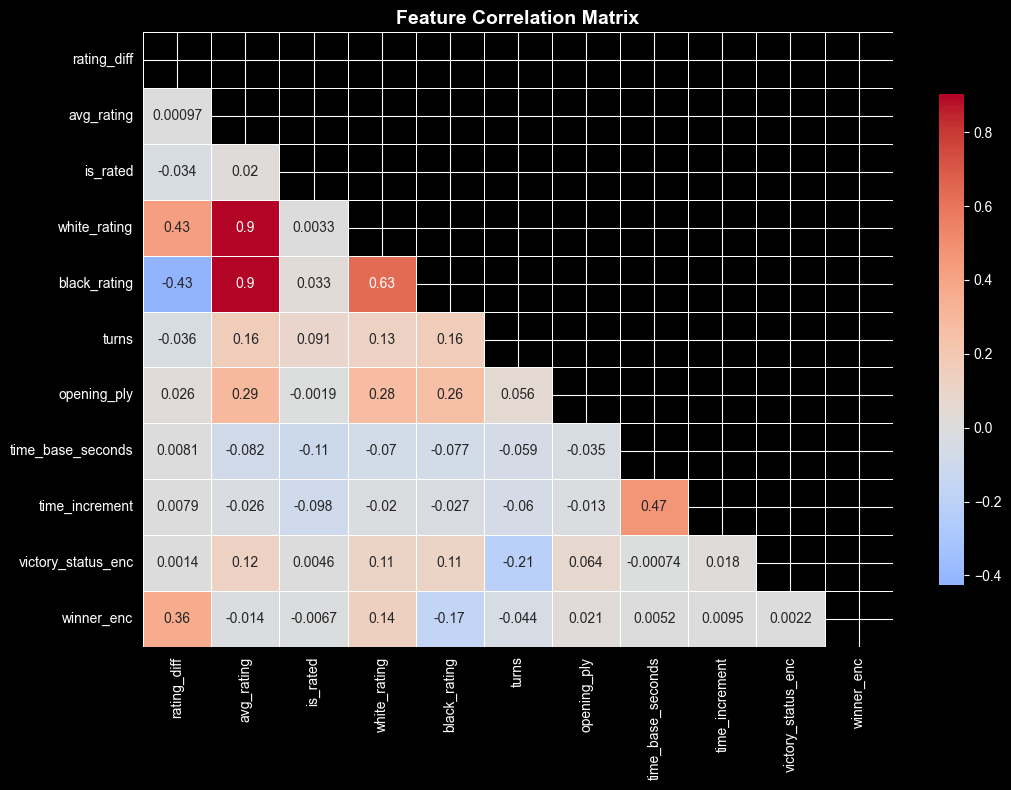

In [32]:
# Correlation matrix
corr_df = df_model[FEATURES + ['winner_enc']].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figures/fig_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

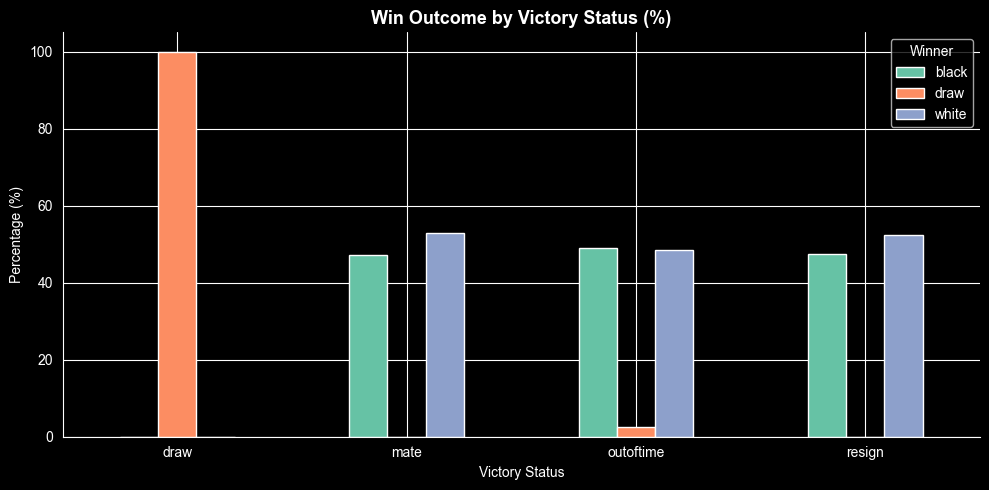

In [33]:
# Victory status breakdown
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df_model['victory_status'], df_model['winner'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title("Win Outcome by Victory Status (%)", fontsize=13, fontweight='bold')
ax.set_xlabel("Victory Status")
ax.set_ylabel("Percentage (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Winner')
plt.tight_layout()
plt.savefig("figures/fig_victory_status.png", dpi=150, bbox_inches='tight')
plt.show()

# Baseline Models